<a href="https://colab.research.google.com/github/chingbsmtry11/First-Program/blob/main/Classification_Concepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##DAY 6 RECAP



1.   What is regression?
*    Regression is a ML method used to predict the relationship between variables.

2.   What is cross-validation?
*    It tests a model on different parts of the data to check how well it performs.

3.   What is K-Fold Cross-Validation?
*    It is a type of Cross-Validation which divides data into K folds and tests the model.

4.   What does cv=5 mean?
*    It means the data is divided into 5 folds.

5.   What is feature engineering?
*    Feature engineering means creating new useful features from existing data.

6.   What is feature leakage?
*    Feature leakage means the information that should not be available when making a prediction is used by the model.

7.   What is a hyperparameter?
*    A hyperparameter is a setting of a model that is chosen before training.

8.   What is GridSearchCV?
*    GridSearchCV is a method used to find the best hyperparameter methods for a ML model.

9.   Why should the test set remain untouched during tuning?
*    The test set should remain untouched during the tuning because it may give us unbiased or overfited data.

10.   What is Random Forest?
*     A model that combines many decision trees to make better predictions.

11.   What is Overfitting?
*     When a model learns the training data and performs poorly on new data.

12.   Why should experiments be documented?
*     Experiments should be documented because it keeps tracks of what was done,what worked and what didn't.

13.   Why should the complete pipeline be saved?
*    The complete pipeline should be saved so, the same preprocessing and model steps can be reused later.

14.   What is reproducibility?
*     The ability to repeat the same experiment and get consistent result.

15.   Why doesn't a high score on synthetic data prove real-world usefulness?
*     A high score on synthetic data doesn't prove real-world usefulness because it the dataset am using is too small compared to real-world data, and it doesn't have real-world conditions and complexity.




##RECAP

On Day 6, i learned about classification, cross-validation, feature engineering, feature leakage, hyperparameters, GridSearchCV, Random Forest and Overfitting. I also learned how to evaluate and save a ML pipeline. Classification predicts categories and Regression predicts numerical values.



##STEP 2

In [1]:
import pandas as rb
import numpy as kb

kb.random.seed(42)

n = 200

df = rb.DataFrame({
    "age": kb.random.randint(18, 75, n),
    "weight_kg": kb.random. normal(65,12, n),
    "height_cm": kb.random.normal(165, 10, n),
    "blood_pressure_systolic": kb.random.normal(125, 15, n),
    "blood_pressure_diastolic": kb.random.normal(80, 10, n),
    "visits": kb.random.randint(1, 10, n),
    "village": kb.random.choice(["village_A", "village_B", "village_C"], n),
    "dosha_type": kb.random.choice(["vata", "pitta", "kapha"], n)
})

risk_score = (
    0.03 * df["age"]
    + 0.04 * df["blood_pressure_systolic"]
    + 0.08 * df["visits"]
    + kb.random.normal(0, 2, n)
)

df["risk_class"] = (
    risk_score > risk_score.median()
).astype(int)

df.head()

,age,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,village,dosha_type,risk_class
0,56,66.164931,162.918777,124.880410,76.390338,1,village_B,pitta,1
1,69,76.623740,160.069991,147.199162,91.593298,9,village_A,pitta,1
2,46,56.575363,159.106352,126.160525,69.189367,9,village_C,pitta,1
3,32,61.068054,173.496021,112.080737,86.159356,5,village_B,vata,0
4,60,60.294702,168.570155,147.846861,85.931013,4,village_A,vata,1


##STEP 3

In [2]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.describe(include="all")

   age  weight_kg   height_cm  blood_pressure_systolic  \
0   56  66.164931  162.918777               124.880410   
1   69  76.623740  160.069991               147.199162   
2   46  56.575363  159.106352               126.160525   
3   32  61.068054  173.496021               112.080737   
4   60  60.294702  168.570155               147.846861   

   blood_pressure_diastolic  visits    village dosha_type  risk_class  
0                 76.390338       1  village_B      pitta           1  
1                 91.593298       9  village_A      pitta           1  
2                 69.189367       9  village_C      pitta           1  
3                 86.159356       5  village_B       vata           0  
4                 85.931013       4  village_A       vata           1  
(200, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  ----

,age,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,village,dosha_type,risk_class
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200,200,200.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,village_A,vata,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,73,70,NaN
mean,45.260000,65.321334,165.384604,124.228398,80.835801,4.880000,NaN,NaN,0.500000
std,16.040852,12.235523,9.645644,15.088869,9.587476,2.638257,NaN,NaN,0.501255
min,18.000000,26.104792,141.980788,84.546700,59.180706,1.000000,NaN,NaN,0.000000
25%,31.750000,56.371167,158.457799,114.118263,74.280308,2.000000,NaN,NaN,0.000000
50%,45.000000,65.830190,165.089181,124.175903,80.560201,5.000000,NaN,NaN,0.500000
75%,59.000000,72.659445,171.829776,133.864993,86.626131,7.000000,NaN,NaN,1.000000


In [3]:
df["risk_class"].value_counts()

,count
risk_class,
1,100
0,100


##EXERCISE



1.   How many rows?
*    Rows: 200.

2.   How many columns?
*    Columns: 9.

1.   Which columns are numerical?
*    Numerical columns: age, weight_kg, height_cm, blood_pressure_systolic, blood_pressure_diastolic, risk_class.

1.   Which are categorical?
*    Categorical column: village, dosha_type.

1.   What is the target?
*    risk_class.

1.   How many classes exist?
*    2.

1.   Are there missing values and duplicates?
*    Nope.



##STEP 4

risk_class
1    100
0    100
Name: count, dtype: int64
risk_class
1    0.5
0    0.5
Name: proportion, dtype: float64


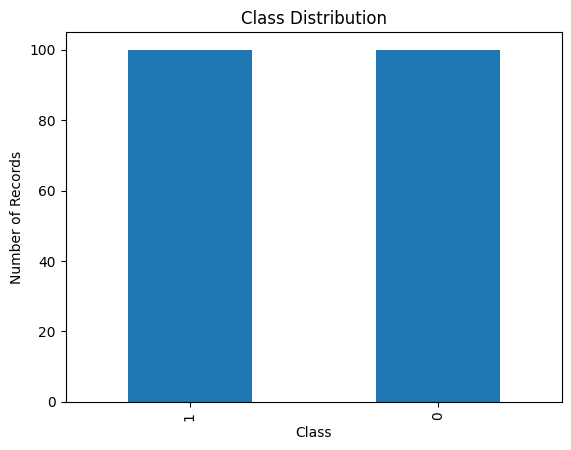

In [4]:
print(df["risk_class"].value_counts())
print(df["risk_class"].value_counts(normalize=True))

import matplotlib.pyplot as fcb

df["risk_class"].value_counts().plot(kind="bar")
fcb.xlabel("Class")
fcb.ylabel("Number of Records")
fcb.title("Class Distribution")
fcb.show()

## Determine whether the classes are balanced. Consider why accuracy alone may be misleading when one class dominates.



*    From the above chart, we can observe that the classes are balanced. Accuracy alone can be misleading when one class dominates because a model can predict the majority class most of the time and still have high accuracy while performing poorly on the minority class.




##STEP 5


In [5]:
df["height_m"] = df["height_cm"]/100

df["bmi"] = (
    df["weight_kg"] /
    df["height_m"] ** 2
)

df["bp_difference"] = (
    df["blood_pressure_systolic"]
    - df["blood_pressure_diastolic"]
)

##EXERCISE



1.   Explain why BMI and blood-pressure difference might be useful representations. Remember that predictive usefulness does not establish causation.
*    BMI combines weight and height into one feature. It can give the model more useful representation.




##STEP 6

In [6]:
numeric_features = [
    "age", "weight_kg", "height_cm", "bmi",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "bp_difference", "visits"
]

categorical_features = [
    "village", "dosha_type"
]

features = numeric_features + categorical_features
target = "risk_class"

x = df[features]
y = df[target]

##STEP 7

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state= 42,
    stratify = y
)

##STEP 8

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features)
])

##STEP 9

In [9]:
from sklearn.linear_model import LogisticRegression


logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'weight_kg',
                                                   'height_cm', 'bmi',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'bp_difference', 'visits']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['village', 'dosha_type'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

##STEP 10

In [10]:
y_pred = logistic_pipeline.predict(x_test)

y_probability = (
    logistic_pipeline
    .predict_proba(x_test)[:, 1]
)

print(y_pred[:10])
print(y_probability[:10])

[0 1 1 1 1 0 1 1 0 1]
[0.206435   0.65610024 0.77198005 0.84464409 0.55697984 0.48514199
 0.55638514 0.93113573 0.39960601 0.68435026]


##STEP 11

1.   What is a classification threshold?
*    A threshold is the probablity value used to decide whether a prediction is Class 0 or Class 1. Usually, it os 0.50.

2.   What happens if the threshold is increased?
*    Fewer samples are predicted as Class 1.

3.   What happens if the threshold is decreased?
*    More samples are predicted as Class 1.

4.   Why should thresholds be selected systematically?
*    To balance false positives and false negatives and choose a threshold suitable for the problem, instead of changing it just to improve the result.

##STEP 12

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score
print("Accuracy:", accuracy)

Accuracy: <function accuracy_score at 0x7b482264e5c0>


##STEP 13

[[13  7]
 [ 7 13]]


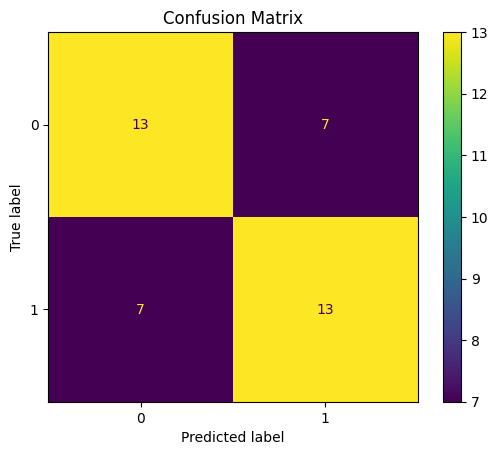

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

fcb.title("Confusion Matrix")
fcb.show()

##STEP 14

In [13]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.65


##STEP 15

In [14]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.65


##STEP 16

In [15]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1:", f1)

F1: 0.65


##STEP 17

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65        20
           1       0.65      0.65      0.65        20

    accuracy                           0.65        40
   macro avg       0.65      0.65      0.65        40
weighted avg       0.65      0.65      0.65        40



##STEP 18

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6675


##STEP 19

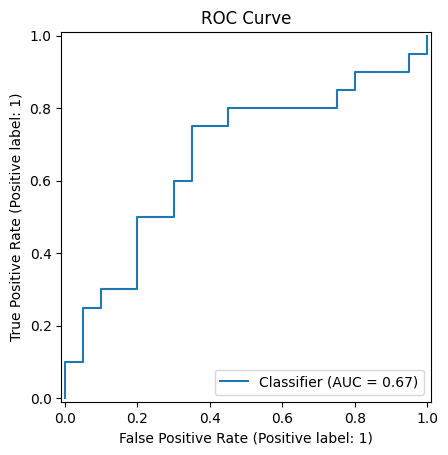

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

fcb.title("ROC Curve")
fcb.show()

##EXERCISE




1.   What does the ROC curve represent?
*    The ROC curve shows how well a classification model distinguishes between the two classes by comparing: True Positive Rate(TPR) and False Positive Rate(FPR).

1.   What does AUC mean?
*    Area Under the Curve(AUC) measures how well the model seperates the two classes.

2.   Why are probility predictions used?
*    Probability predictions show how confident the model is about each class.

2.   Why is ROC-AUC not clinical validation?
*    ROC-AUC only measures the model's classification performance on the dataset. ROC-AUC evaluates model discrimination; it does not establish clinical validity or causation.


##STEP 20

In [19]:
from sklearn.model_selection import cross_val_score

cv_accuracy = cross_val_score(
    logistic_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Accuracy scores:", cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())
print("Standard deviation:", cv_accuracy.std())

cv_f1 = cross_val_score(
    logistic_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores:", cv_f1)
print("Mean F1:", cv_f1.mean())
print("F1 standard deviation:", cv_f1.std())

Accuracy scores: [0.5625  0.71875 0.65625 0.59375 0.59375]
Mean Accuracy: 0.625
Standard deviation: 0.05590169943749474
F1 scores: [0.5625     0.70967742 0.66666667 0.58064516 0.60606061]
Mean F1: 0.6251099706744868
F1 standard deviation: 0.055024755068447395


##STEP 21

In [20]:
error_analysis = x_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred
error_analysis["Probability"] = y_probability
error_analysis["Correct"] = (
    error_analysis["Actual"] == error_analysis["Predicted"]
)

errors = error_analysis[
    error_analysis["Correct"] == False
]

errors

,age,weight_kg,height_cm,bmi,blood_pressure_systolic,blood_pressure_diastolic,bp_difference,visits,village,dosha_type,Actual,Predicted,Probability,Correct
39,68,58.958292,171.283455,20.096206,111.435251,72.216953,39.218298,1,village_C,vata,0,1,0.556980,False
7,56,68.132663,168.072995,24.119010,122.144920,67.488864,54.656056,5,village_B,vata,1,0,0.485142,False
56,26,50.156591,150.519157,22.138310,133.656082,81.867668,51.788414,4,village_C,pitta,0,1,0.556385,False
123,52,72.816695,177.776768,23.039919,108.117664,81.965548,26.152117,8,village_B,kapha,1,0,0.399606,False
171,69,64.285696,165.352636,23.512137,116.797116,64.842559,51.954557,9,village_C,pitta,0,1,0.684350,False
16,41,87.634231,177.776649,27.728370,116.114091,67.195706,48.918385,7,village_B,vata,1,0,0.190325,False
194,23,90.596400,157.436493,36.551073,106.668083,86.818915,19.849168,3,village_B,kapha,1,0,0.168956,False
5,25,47.437821,158.070904,18.985448,133.083651,76.904536,56.179115,6,village_A,kapha,0,1,0.505770,False
87,31,82.442409,166.833420,29.619967,136.562978,77.524814,59.038164,1,village_A,pitta,1,0,0.242301,False
28,29,78.713874,168.241664,27.808924,126.489985,76.363878,50.126107,9,village_A,pitta,1,0,0.271075,False


##EXERCISE



1.   How many errors occurred?
*    Nope.

2.   How many false positives?
*    13.

3.   How many false negatives?
*    0.

4.   Are errors concentrated in one class?
*    Nope.

5.   Are there unusual feature values?
*    Nope.

6.   Are some cases close to the 0.50 threshold?
*    Yup, there are few.

##STEP 22

In [21]:
comparison = rb.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Class_1": y_probability
})

comparison.head(20)

,Actual,Predicted,Probability_Class_1
0,0,0,0.206435
1,1,1,0.656100
2,1,1,0.771980
3,1,1,0.844644
4,0,1,0.556980
5,1,0,0.485142
6,0,1,0.556385
7,1,1,0.931136
8,1,0,0.399606
9,0,1,0.684350


##STEP 24

In [22]:
classification_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print(classification_results)

results_df = rb.DataFrame([classification_results])
results_df.to_csv(
    "day7_classification_results.csv",
    index=False
)

{'Accuracy': <function accuracy_score at 0x7b482264e5c0>, 'Precision': 0.65, 'Recall': 0.65, 'F1': 0.65, 'ROC_AUC': np.float64(0.6675)}


##STEP 25

In [23]:
import joblib
joblib.dump(
    logistic_pipeline,
    "day7_logistic_classification_pipeline.pkl"
)

['day7_logistic_classification_pipeline.pkl']

##STEP 26

In [24]:
loaded_model = joblib.load(
    "day7_logistic_classification_pipeline.pkl"
)

loaded_pred = loaded_model.predict(x_test)

kb.array_equal(
    y_pred,
    loaded_pred
)

True

##EXERCISE



1.   Explain why this verification is useful.
*    This verification is useful to confirm that the saved and reloaded model produces the same prediction as the original model, ensuring the model saved and reloaded correctly.



##STEP 27



*    Use the same random seed.
*    Confirm the same dataset is generated.
*    Confirm the same train/test split occurs.
*    Confirm the same preprocessing occurs.
*    Confirm the same predictions and metrics are obtained.



1.   Why is reproducibility important in ML engineering?
*    Reproducibility means getting the same consistent results when the same process, data is used again. Reproducibility is important because it makes ML results reliable, repeatable and easier to test, debug and compare.



##DAY 7 MINI PROJECT

In [25]:
import pandas as rb
import numpy as kb
import matplotlib.pyplot as fcb
csv_text = """patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
P001,21,abc,kapha,56,150,110,80,4,400
P002,55,qwe,vata,55,167,120,70,3,300
P003,24,bnm,kapha,76,170,140,90,4,400
P004,34,mnb,vata,64,145,130,100,5,500
P005,76,abc,pitta,54,170,120,90,4,400
P006,33,abc,vata,77,169,130,100,2,200
P007,32,lkj,pitta,80,150,120,90,5,500
P008,66,hgf,kapha,86,144,140,100,3,300
P009,23,poi,pitta,46,150,140,100,4,400
P010,19,yui,vata,46,167,130,90,2,200
P011,45,lkj,pitta,76,163,120,80,3,300
P012,32,dfg,vata,55,150,110,90,5,500
P013,29,xcv,kapha,75,157,120,100,1,100
P014,34,vgy,vata,65,159,120,90,4,400
P015,26,wdv,vata,56,160,110,80,2,200
P016,54,ggf,kapha,54,165,110,90,3,300
P017,23,hdd,vata,63,170,120,90,4,400
P018,42,yug,kapha,66,180,110,90,2,200
P019,32,ghu,,56,160,110,100,5,500
P020,34,fde,pitta,54,170,110,80,3,300
P021,23,hdg,pitta,54,180,120,90,2,200
P022,53,ghg,vata,55,159,110,90,3,300
P023,35,abc,kapha,75,146,110,70,6,600
P024,44,abc,vata,86,168,120,80,3,300
P025,27,hjg,pitta,56,175,120,90,4,400
P026,25,kxs,kapha,46,187,130,100,5,500
P027,34,cxj,vata,74,190,120,90,3,300
P028,45,gfx,pitta,50,165,130,100,5,500
P029,26,wdv,vata,56,167,110,80,2,200
P030,23,hdd,vata,63,173,120,90,4,400
P031,34,tgf,vata,78,165,130,80,7,700
P032,26,hcs,kapha,56,150,110,90,3,300
P033,66,jde,pitta,70,180,120,80,5,500
P034,47,poi,kapha,68,175,120,80,4,400
P034,47,poi,kapha,68,175,120,80,4,400
P035,45,mnb,vata,64,160,120,70,4,400
P036,57,mnb,vata,57,178,120,90,1,100
P037,67,lkj,vata,70,180,110,70,3,300
P038,57,gye,kapha,87,189,130,90,6,600
P039,45,mnb,vata,67,169,120,80,3,300
P039,45,mnb,vata,67,169,120,80,3,300
P040,30,poi,kapha,75,178,110,80,5,500
P041,57,abc,kapha,68,172,120,80,3,300
P042,31,qwe,vata,59,165,110,70,2,200
P043,48,bnm,pitta,72,168,130,90,4,400
P044,22,mnb,vata,51,158,110,70,2,200
P045,63,abc,kapha,78,175,140,90,5,500
P046,37,lkj,pitta,65,162,120,80,3,300
P047,29,hgf,vata,57,170,110,70,4,400
P048,71,poi,kapha,82,168,130,90,6,600
P049,41,yui,pitta,69,176,120,80,3,300
P050,25,dfg,vata,53,160,110,70,2,200
P051,52,xcv,kapha,74,171,130,80,4,400
P052,36,vgy,pitta,61,165,120,80,5,500
P053,68,wdv,vata,70,160,140,90,3,300
P054,27,ggf,kapha,49,155,110,70,2,200
P055,44,hdd,pitta,76,178,130,90,5,500
P056,58,yug,vata,67,169,120,80,4,400
P057,33,ghu,kapha,63,173,110,70,3,300
P058,46,hdg,pitta,71,166,130,80,6,600
P059,20,ghg,vata,48,157,110,70,2,200
P060,60,abc,kapha,80,180,140,90,5,500
P061,39,qwe,pitta,66,172,120,80,4,400
P062,24,hjg,vata,52,164,110,70,3,300
P063,55,kxs,kapha,75,177,130,90,5,500
P064,43,cxj,pitta,68,169,120,80,4,400
P065,30,gfx,vata,58,161,110,70,2,200
P066,69,wdv,kapha,84,174,140,90,6,600
P067,35,hdd,pitta,62,167,120,80,3,300
P068,50,tgf,vata,73,179,130,90,5,500
P069,28,,kapha,55,153,110,70,2,200
P070,47,jde,pitta,70,176,120,80,4,400
P071,32,poi,vata,60,168,110,70,3,300
P072,61,gye,kapha,79,181,140,90,5,500
P073,26,mnb,pitta,54,159,120,80,2,200
P074,45,lkj,vata,67,171,130,80,4,400
P075,73,abc,kapha,86,176,140,90,6,600
P076,38,qwe,pitta,64,164,120,80,3,300
P077,21,bnm,vata,50,156,110,70,2,200
P078,56,mnb,kapha,77,170,130,90,5,500
P079,34,lkj,pitta,59,162,120,80,4,400
P080,49,hgf,vata,72,175,130,80,3,300
P081,64,poi,kapha,81,178,140,90,5,500
P082,29,yui,pitta,56,160,110,70,2,200
P083,40,dfg,vata,63,169,120,80,4,400
P084,67,xcv,kapha,78,173,130,90,6,600
P085,23,vgy,pitta,51,157,110,70,3,300
P086,53,wdv,vata,69,171,120,80,5,500
P087,31,ggf,kapha,58,165,110,70,2,200
P088,59,hdd,pitta,76,177,130,90,4,400
P089,36,yug,vata,62,168,120,80,3,300
P090,70,ghu,kapha,83,180,140,90,5,500
P091,42,hdg,pitta,67,174,120,80,4,400
P092,27,ghg,vata,55,159,110,70,2,200
P093,51,abc,kapha,74,172,130,90,5,500
P094,33,qwe,pitta,60,166,120,80,3,300
P095,65,hjg,vata,71,170,130,80,4,400
P096,46,kxs,kapha,79,176,140,90,6,600
P097,19,cxj,pitta,47,154,110,70,2,200
P098,57,gfx,vata,68,169,120,80,5,500
P099,37,tgf,kapha,64,163,130,90,3,300
P100,62,hcs,pitta,77,179,140,90,4,400
"""

with open("health_camp.csv", "w") as f:
  f.write(csv_text)
df = rb.read_csv("health_camp.csv")
df


,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
0,P001,21,abc,kapha,56,150,110,80,4,400
1,P002,55,qwe,vata,55,167,120,70,3,300
2,P003,24,bnm,kapha,76,170,140,90,4,400
3,P004,34,mnb,vata,64,145,130,100,5,500
4,P005,76,abc,pitta,54,170,120,90,4,400
...,...,...,...,...,...,...,...,...,...,...
97,P096,46,kxs,kapha,79,176,140,90,6,600
98,P097,19,cxj,pitta,47,154,110,70,2,200
99,P098,57,gfx,vata,68,169,120,80,5,500
100,P099,37,tgf,kapha,64,163,130,90,3,300


In [26]:
rb.set_option("display.max_rows", None)

df


,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
0,P001,21,abc,kapha,56,150,110,80,4,400
1,P002,55,qwe,vata,55,167,120,70,3,300
2,P003,24,bnm,kapha,76,170,140,90,4,400
3,P004,34,mnb,vata,64,145,130,100,5,500
4,P005,76,abc,pitta,54,170,120,90,4,400
5,P006,33,abc,vata,77,169,130,100,2,200
6,P007,32,lkj,pitta,80,150,120,90,5,500
7,P008,66,hgf,kapha,86,144,140,100,3,300
8,P009,23,poi,pitta,46,150,140,100,4,400
9,P010,19,yui,vata,46,167,130,90,2,200


In [27]:
#Inspecting the dataset


df.shape

(102, 10)

In [28]:
df.info

<bound method DataFrame.info of     patient_id  age village dosha_type  weight_kg  height_cm  \
0         P001   21     abc      kapha         56        150   
1         P002   55     qwe       vata         55        167   
2         P003   24     bnm      kapha         76        170   
3         P004   34     mnb       vata         64        145   
4         P005   76     abc      pitta         54        170   
5         P006   33     abc       vata         77        169   
6         P007   32     lkj      pitta         80        150   
7         P008   66     hgf      kapha         86        144   
8         P009   23     poi      pitta         46        150   
9         P010   19     yui       vata         46        167   
10        P011   45     lkj      pitta         76        163   
11        P012   32     dfg       vata         55        150   
12        P013   29     xcv      kapha         75        157   
13        P014   34     vgy       vata         65        159   
14        P015   26     wdv       vata         56        160   
15        P016   54     ggf      kapha         54        165   
16        P017   23     hdd       vata         63        170   
17        P018   42     yug      kapha         66        180   
18        P019   32     ghu        NaN         56        160   
19        P020   34     fde      pitta         54        170   
20        P021   23     hdg      pitta         54        180   
21        P022   53     ghg       vata         55        159   
22        P023   35     abc      kapha         75        146   
23        P024   44     abc       vata         86        168   
24        P025   27     hjg      pitta         56        175   
25        P026   25     kxs      kapha         46        187   
26        P027   34     cxj       vata         74        190   
27        P028   45     gfx      pitta         50        165   
28        P029   26     wdv       vata         56        167   
29        P030   23     hdd       vata         63        173   
30        P031   34     tgf       vata         78        165   
31        P032   26     hcs      kapha         56        150   
32        P033   66     jde      pitta         70        180   
33        P034   47     poi      kapha         68        175   
34        P034   47     poi      kapha         68        175   
35        P035   45     mnb       vata         64        160   
36        P036   57     mnb       vata         57        178   
37        P037   67     lkj       vata         70        180   
38        P038   57     gye      kapha         87        189   
39        P039   45     mnb       vata         67        169   
40        P039   45     mnb       vata         67        169   
41        P040   30     poi      kapha         75        178   
42        P041   57     abc      kapha         68        172   
43        P042   31     qwe       vata         59        165   
44        P043   48     bnm      pitta         72        168   
45        P044   22     mnb       vata         51        158   
46        P045   63     abc      kapha         78        175   
47        P046   37     lkj      pitta         65        162   
48        P047   29     hgf       vata         57        170   
49        P048   71     poi      kapha         82        168   
50        P049   41     yui      pitta         69        176   
51        P050   25     dfg       vata         53        160   
52        P051   52     xcv      kapha         74        171   
53        P052   36     vgy      pitta         61        165   
54        P053   68     wdv       vata         70        160   
55        P054   27     ggf      kapha         49        155   
56        P055   44     hdd      pitta         76        178   
57        P056   58     yug       vata         67        169   
58        P057   33     ghu      kapha         63        173   
59        P058   46     hdg      pitta         71        166   
60        P059   20     ghg       vata         48        157   


In [29]:
df.isnull().sum()

,0
patient_id,0
age,0
village,1
dosha_type,1
weight_kg,0
height_cm,0
blood_pressure_systolic,0
blood_pressure_diastolic,0
visits,0
consultation_fee,0


In [30]:
df.duplicated().sum()

np.int64(2)

In [31]:
df[df.duplicated()]

,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
34,P034,47,poi,kapha,68,175,120,80,4,400
40,P039,45,mnb,vata,67,169,120,80,3,300


In [32]:
numerical_features = df.select_dtypes(include="number").columns.drop("consultation_fee").tolist()

categorical_features = df.select_dtypes(include="object").columns.drop("patient_id").tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)


Numerical: ['age', 'weight_kg', 'height_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'visits']
Categorical: ['village', 'dosha_type']


In [33]:
target = "consultation_fee"

print("Target:", target)

Target: consultation_fee


In [34]:
df["consultation_fee"].value_counts()

,count
consultation_fee,
300,26
400,25
500,21
200,19
600,8
100,2
700,1


In [35]:
##Creating meaningful engineered features

#BMI = weight_kg / height_m**2

#Creating a new feature:

df["height_m"] = df["height_cm"]/10

df["bmi"]= (
    df["weight_kg"]/
    (df["height_m"]**2)
)

df[["weight_kg", "height_cm", "bmi"]].head()

,weight_kg,height_cm,bmi
0,56,150,0.248889
1,55,167,0.197210
2,76,170,0.262976
3,64,145,0.304400
4,54,170,0.186851




1.   Explain possible leakage.
*    Possible leakage happens when a test data gets into training data.





In [36]:
#Performing a stratified train/test split.

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
#Building preprocessing pipeline


numerical_feature = [
    "age",
    "weight_kg",
    "height_cm",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "visits",
    "bmi"
]

categorical_feature = [
    "village",
    "dosha_type"
]



#Creating Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#Combining them

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [38]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [39]:
#Training a logistic regression

logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'weight_kg',
                                                   'height_cm',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'visits']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['village', 'dosha_type'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [40]:
#Generating class predictions.

y_pred = logistic_pipeline.predict(x_test)
print(y_pred)

[0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0
 1 1 0]


In [41]:
#Generating probablity prediction.

y_proba = logistic_pipeline.predict_proba(x_test)[:, 1]
print(y_proba)

[0.2062805  0.65547039 0.7820894  0.8434761  0.55593855 0.48244319
 0.55146903 0.93103107 0.39898619 0.68186685 0.18660547 0.17433299
 0.50038586 0.57144944 0.19437769 0.28915152 0.78151012 0.40015057
 0.32711466 0.61835493 0.2713105  0.7095908  0.51796375 0.58735599
 0.24068192 0.53379769 0.26914863 0.80183168 0.48939644 0.24143163
 0.76557675 0.27586994 0.42106974 0.70515713 0.40358785 0.31160305
 0.43971458 0.71688775 0.50153167 0.18827359]


In [42]:
#Calculating metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.65
Precision: 0.65
Recall: 0.65
F1: 0.65
ROC AUC: 0.6575


In [43]:
#Generating a confusion matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[13  7]
 [ 7 13]]


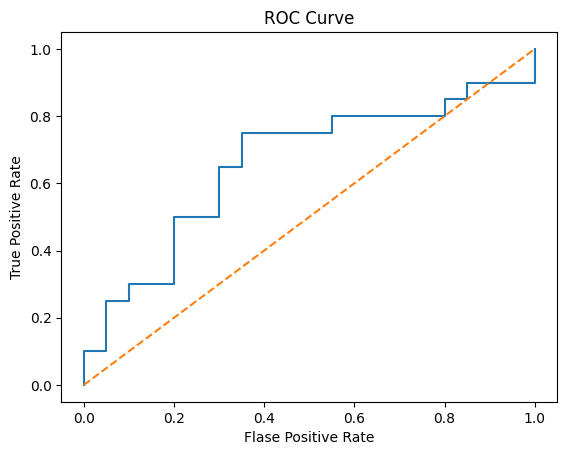

In [44]:
#ROC curve

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fcb.plot(fpr, tpr)
fcb.plot([0, 1], [0, 1], linestyle="--")

fcb.xlabel("Flase Positive Rate")
fcb.ylabel("True Positive Rate")
fcb.title("ROC Curve")
fcb.show()

In [45]:
#Performing 5-fold cross-validation

from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    logistic_pipeline,
    x,
    y,
    cv=cv,
    scoring=["accuracy", "f1"]
)
print(cv_results)

{'fit_time': array([0.05724931, 0.04741073, 0.04911256, 0.08629894, 0.05388045]), 'score_time': array([0.05819345, 0.05886865, 0.04586816, 0.06218886, 0.0448153 ]), 'test_accuracy': array([0.725, 0.6  , 0.675, 0.7  , 0.525]), 'test_f1': array([0.7027027 , 0.61904762, 0.66666667, 0.7       , 0.51282051])}


In [46]:
#Reporting mean CV score and standard deviation

accuracy_scores = cv_results["test_accuracy"]
f1_scores = cv_results["test_f1"]

print("Accuracy Scores:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())
print("Accuracy Standard Deviation:", accuracy_scores.std())

print("\nF1 scores:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("F1 Standard Deviation:", f1_scores.std())

Accuracy Scores: [0.725 0.6   0.675 0.7   0.525]
Mean Accuracy: 0.645
Accuracy Standard Deviation: 0.07314369419163895

F1 scores: [0.7027027  0.61904762 0.66666667 0.7        0.51282051]
Mean F1: 0.6402475002475002
F1 Standard Deviation: 0.07050681950319858


In [47]:
#Investigating False positives and false negatives.

results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred
results["Probability"] = y_proba

false_positives = results[
    (results["Actual"] == 0) &
    (results["Predicted"] == 1)
]

false_negatives = results[
    (results["Actual"] == 1) &
    (results["Predicted"] == 0)
]

print("False Positives:")
display(false_positives)

print("False Negatives:")
display(false_negatives)

False Positives:


,age,weight_kg,height_cm,bmi,blood_pressure_systolic,blood_pressure_diastolic,bp_difference,visits,village,dosha_type,Actual,Predicted,Probability
39,68,58.958292,171.283455,20.096206,111.435251,72.216953,39.218298,1,village_C,vata,0,1,0.555939
56,26,50.156591,150.519157,22.138310,133.656082,81.867668,51.788414,4,village_C,pitta,0,1,0.551469
171,69,64.285696,165.352636,23.512137,116.797116,64.842559,51.954557,9,village_C,pitta,0,1,0.681867
5,25,47.437821,158.070904,18.985448,133.083651,76.904536,56.179115,6,village_A,kapha,0,1,0.500386
167,68,56.507966,154.647577,23.627808,124.638124,84.714156,39.923968,4,village_A,pitta,0,1,0.801832
165,59,59.189191,157.071272,23.991030,125.888277,74.292537,51.595739,7,village_A,pitta,0,1,0.705157
105,62,69.623809,160.308243,27.092312,117.349754,90.531529,26.818225,9,village_A,pitta,0,1,0.716888


False Negatives:


,age,weight_kg,height_cm,bmi,blood_pressure_systolic,blood_pressure_diastolic,bp_difference,visits,village,dosha_type,Actual,Predicted,Probability
7,56,68.132663,168.072995,24.119010,122.144920,67.488864,54.656056,5,village_B,vata,1,0,0.482443
123,52,72.816695,177.776768,23.039919,108.117664,81.965548,26.152117,8,village_B,kapha,1,0,0.398986
16,41,87.634231,177.776649,27.728370,116.114091,67.195706,48.918385,7,village_B,vata,1,0,0.186605
194,23,90.596400,157.436493,36.551073,106.668083,86.818915,19.849168,3,village_B,kapha,1,0,0.174333
87,31,82.442409,166.833420,29.619967,136.562978,77.524814,59.038164,1,village_A,pitta,1,0,0.240682
28,29,78.713874,168.241664,27.808924,126.489985,76.363878,50.126107,9,village_A,pitta,1,0,0.269149
68,31,50.704358,168.227186,17.916490,130.916782,71.416422,59.500360,8,village_C,kapha,1,0,0.489396


In [48]:
#Saving results

results.to_csv("day7_prediction.csv", index=False)

In [49]:
#Reloading the pipeline and verifying predictions

joblib.dump(
    logistic_pipeline,
    "day7_logistic_classification_pipeline.pkl"
)

['day7_logistic_classification_pipeline.pkl']

In [50]:
loaded_model = joblib.load(
    "day7_logistic_classification_pipeline.pkl"
)

loaded_pred = loaded_model.predict(x_test)

print(kb.array_equal(y_pred, loaded_pred))

True


##Writing five observations, three limitations and three future questions.


#Five Observation

*    The Logistic Pregression model was able to classify the two health risk factors.
*    Accuracy shows the overall percentage of correct predictions.
*    Precision shows how many predicted positive cases were actually positive.
*    Recall shows how many actual positive cases were correctly detected.
*    ROC-AUC shows how well the model separes the two classes.

#Limitations

*    The dataset is synthetic/fictional, it doesn't represent any real patients informations and all.
*   The dataset is kinda small for a real world records.
*   Logistic Regression may not work smoothly in complex relationships.

##DAY 7 Learning Report



*   Topics i learned on day 7, Classification, binary classification, class labels, stratified splitting, Logistic Regression, probablity prediction, threshold, confusion matrix, accuracy, precision, recall, F1-score, ROC-AUC, class imbalance, cross-validation, error analysis, pipleine saving and reproducibility.

*   Classification problem: The classification problem is to predict the health-risk class(0-1) of a person using their health-related feature.

*   Features used:

Features: age, village, dosha_type, blood_pressure_systolic, blood_pressure_diastolic, weight_kg, height_cm, visits, consultation_fee, bmi and bp_difference.

Engineered features: bmi, bp_difference.

Numerical features: age, weight_kg, height_cm, blood_pressure_systolic, blood_pressure_diastolic, visits

Categorical features: village, dosha_type.

*   Feature Engineering: I created few useful features such as BMI, Blood Pressure Difference(bp_difference) to provide additional information to the model.

*   BMI: Body Mass Index(BMI) is a value calculated by using a person's weight and height.

*   BP Difference: BP difference means the difference between systolic and diastolic blood pressure.

*   CLass Distribution: Include class counts and percentage.

*   Model:

Logistic Regression: Logistic Regression is a ML algorithm used for classification.

*   Classification results: include accuracy, precision, recall, F1-score and ROC-AUC.

*   Confusion matrix:

True Positive: The model predicted positive, and the actual result is also positive.

True Negative: The model predicted negative and the actual result is also negative.

False Positive: The model predicted positive but the actual result is negative.

False Negative: The model predicted negative but the actual result is positive.

*   Cross-Validation: Include mean and standard deviation for Accuracy and F1.

*   Error Analysis:

False Positive: The model predicts Class 1 but the actual result is Class 0.

False Negative: The model predicts Class 0 but the actual result is Class 1.

Misunderstanding: The model predicts the wrong class.

Overfitting: The model performs very well on training data but poorly on new data.

Underfitting: The model is too simple and performs poorly on both the training and testing data.


*   Limitations:

The dataset is too small it contains only 100 records.

It is a synthetic dataset it may not work in the same way as a real world datasets.

Logistic Regression may not work well in complex relationship between features.


*   Problems i faced:

I faced some confusion while understanding the confusion matrix and classification matrics.

I faced some errors while creating and using the ML pipeline.

*   Questions i still have:

How can i improve the model's performance?

Which features are most important for predictions?



##Final Day 7 Test



1.   What is classification?
*    Classification is a type of ML that used to predict a class or category.

2.   What is the difference between regression and classification?
*    The difference between regression and classification is that regression predicts a contionous numerical value whereas classification predicts a category or class.

3.   What is binary classification?
*    Binary classification is a type of ML task where the goal is to predict one of two possible classes.

4.   What is multi classification?
*    Multi classification is a type of ML where the model predicts one class out of three or more possible classes.

5.   What is a class label?
*    A class label is the category we want the ML model to predict.

6.   Why is stratify=y useful?
*    stratify=y is useful when splitting data because it keeps the same proportion of each class in both the training and testing data.

7.   What is Logistic Regression?
*    Logistic Regression is a ML algorithm mainly used for classification, especially binary classification.

8.   Does Logistic Regression only perform regression?
*    No.

9.   What does predict() return?
*    predict() gives the model's final prediction.

10.  What does predict_proba() return?
*    predict_proba() returns the probability of each class.

11.  What is a classification threshold?
*    Classification threshold is the probability cutoff that decides which class the model predicts.

12.  What is a confusion matrix?
*    A confusion matrix is a table that shows how well a classification model predicted the class.

13.  What is a true positive?
*    The model predicted positive, and the actual result is also positive.

14.  What is a true negative?
*    The model predicted negative, and the actual result is also negative.

15.  What is  a false positive?
*    The model predicted positive, but the actual result is negative.

16.  What is false negative?
*    The model predicted negative, but the actual result is positive.

17.  What is accuracy?
*    Accuracy tells us how many predictions the model got correct out of all prediction.

18.  What is precision?
*    Precision tells us how many of the predictions made as positive were actually correct.

19.  What is recall?
*    Recall tells us how many of the actual positive cases the model correctly found.

20.  What is F1-score?
*    F1 score is a measure that combines precision and recall into one score.

21.  What is ROC-AUC?
*    ROC-AUC measures how well a classification model can distinguish between two classes.

22.  Why can accuracy be misleading with imbalanced classes?
*    Accuracy can be misleading when one class is much larger than the other.

23.  What is class imbalance?
*    Class imbalance means that the classes in a dataset are not equally represented.

24.  Why are probablity predictions used for ROC-AUC?
*    Probability predictions are used for ROC-AUC because they show how confident the model is about each class

25.  Why should the test set remain separate?
*    The test set should remain separate because it is used to check how well the model performs on unseen data.

26.  Why should cross-validation be performed only using training data?
*    Cross-validation should be performed only on the training data because the test data must remain unseen.

27.  What is the purpose of a preprocessing pipline?
*    A preprocessing pipeline is used to prepare the data before giving it to the machine learning model.

28.  Why should the complete pipeline be saved?
*    The complete pipeline should be saved so we can reuse the trained model with the same preprocessing steps later.

29.  Why should the saved pipeline be reloaded?
*    The saved pipeline should be reloaded to make sure it works correctly after saving.

30.  Why does a high classification score on synthetic data not prove clinical usefulness?
*    A high classification score on synthetic data does not prove clinical usefulness because it is a artificially created.

